# Evaluations

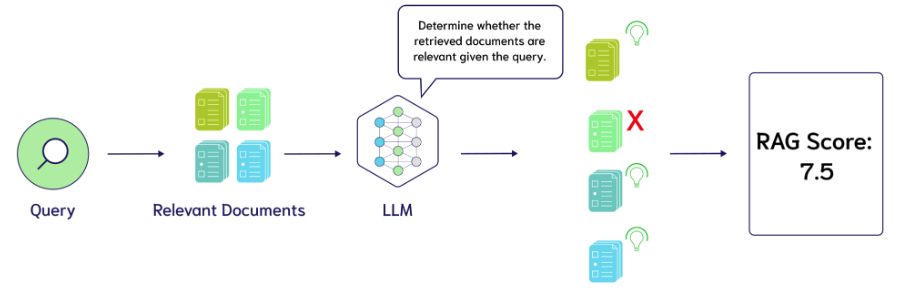

## RAG

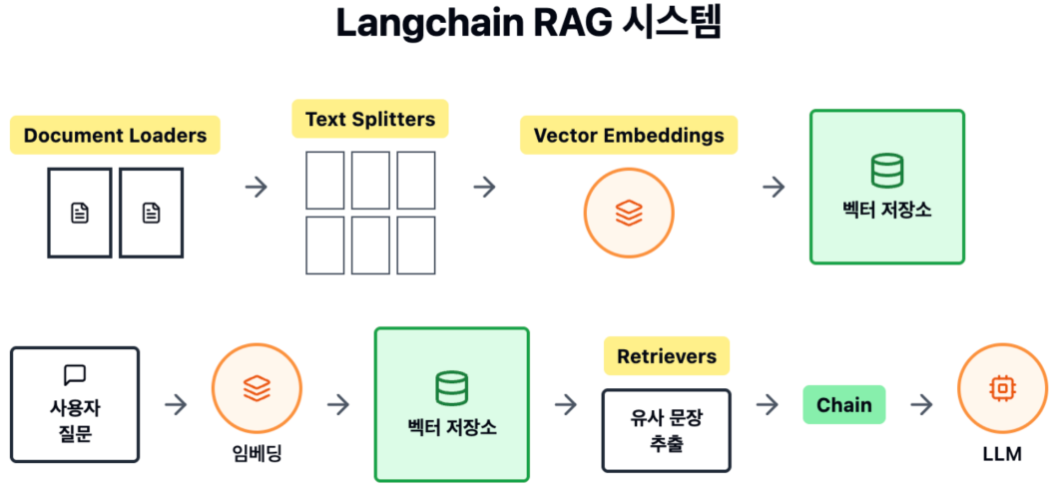

### 단계 1: 문서 로드(Load Documents)

In [ ]:
from langchain_community.document_loaders import PDFPlumberLoader

loader = PDFPlumberLoader("./data/SPRI_AI_Brief_2023년12월호_F.pdf")
docs = loader.load()

In [ ]:
print(f"pdf 페이지 수: {len(docs)}")

### 단계 2: 문서 분할(Split Documents)

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500, chunk_overlap=50)
split_documents = text_splitter.split_documents(docs)

In [ ]:
print(f"저장될 문서의 수: {len(split_documents)}")

### 단계 3: 임베딩(Embedding) 생성
- [OpenAI Key 발급](https://platform.openai.com/api-keys)

In [ ]:
from dotenv import load_dotenv 

load_dotenv()

In [ ]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

### 단계 4: DB 생성(Create DB) 및 저장

In [ ]:
from langchain_chroma import Chroma

vectorstore = Chroma.from_documents(
    documents=split_documents, # 문서 리스트
    embedding=embeddings, # 임베딩 함수
    collection_name="evaluation", # 컬렉션 이름
    persist_directory="./chroma_evaluation" # 영구 저장 경로
)

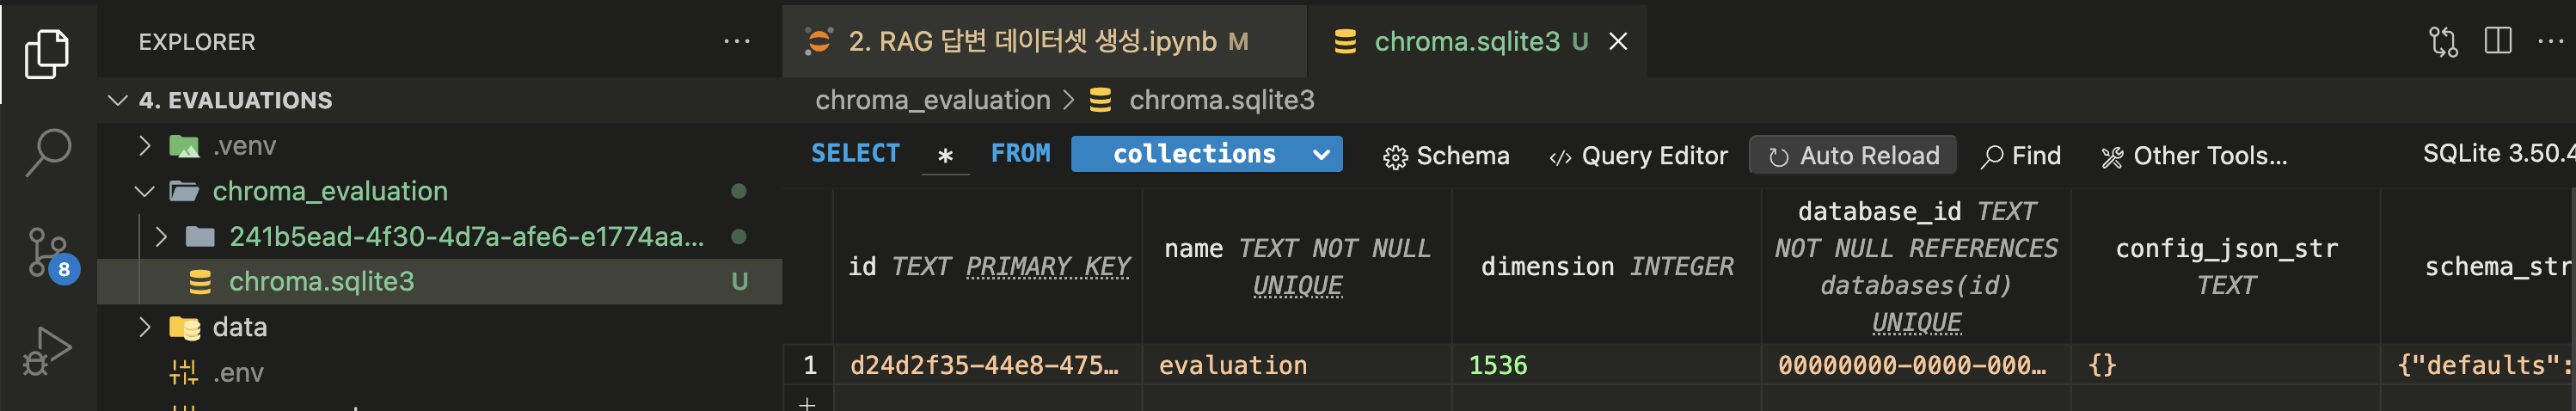

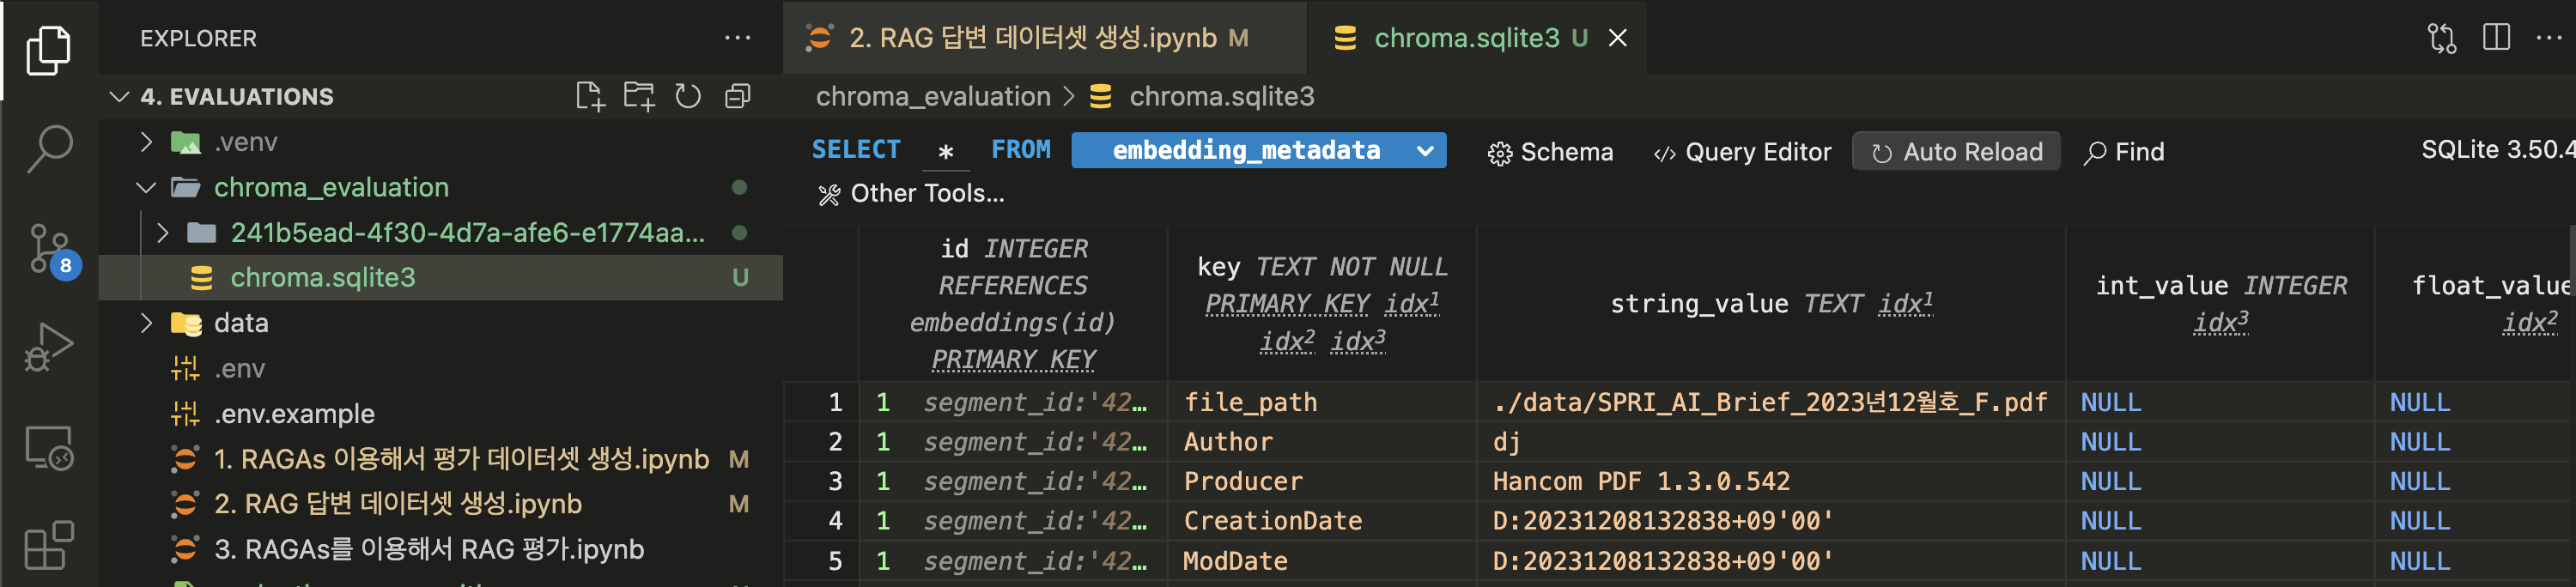

In [ ]:
stats = vectorstore._collection.count()

print(f"현재 문서 수: {stats}")

### 단계 5: 검색기(Retriever) 생성

In [ ]:
# 문서에 포함되어 있는 정보를 검색하고 생성합니다.
retriever = vectorstore.as_retriever()

### 단계 6: 프롬프트 생성(Create Prompt)

In [ ]:
from langchain_core.prompts import PromptTemplate

# 프롬프트를 생성합니다.
prompt = PromptTemplate.from_template(
    template="""
    - 당신은 질의응답 작업을 위한 어시스턴트입니다.
    - 아래에 제공된 검색/추출된 컨텍스트를 활용하여 질문에 답하십시오.
    - 답을 모를 경우, 모른다고 말하십시오.
    - 반드시 한국어로 답변해야 합니다.

    #컨텍스트:
    {context}

    #질문:
    {question}
    """
)


In [ ]:
prompt.input_variables

### 단계7: RAG 체인 생성


#### LLM을 통한 답변 생성

In [ ]:
from langchain_ollama.chat_models import ChatOllama 

# 언어모델(LLM) 생성
llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.1,
    top_p=1.0,
    num_predict=256,
    keep_alive="5m"
)

#### 체인 생성 

In [ ]:
from langchain_core.output_parsers import StrOutputParser

def get_answer_of_llm(dict_param:dict):
    contexts = [
        doc.page_content for doc in dict_param["context"]
    ]

    answer = (prompt | llm | StrOutputParser()).invoke({
        "context" : "\n".join(contexts),
        "question": dict_param["question"]
    })

    return {
        "context": contexts,
        "question": dict_param["question"],
        "answer": answer
    }

In [ ]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda

chain = (
    {
        "context": retriever, 
        "question": RunnablePassthrough()
    }
    | RunnableLambda(get_answer_of_llm)
)

    

### 단계8: 답변 추가 및 저장

#### 질문 로드

- evaluation_ragas 데이터 로드 

In [ ]:
import pandas as pd 

df_evaluation_ragas = pd.read_csv("./data/evaluation_ragas.csv")
df_evaluation_ragas.shape 

| 컬럼명 | 설명 | 데이터 타입 | 예시 값 |
|--------|------|------------|---------|
| **user_input** | 사용자가 입력한 질문(쿼리) | `str` | "바이든 대통령이 발표한 AI 행정명령의 주요 내용은 뭐고, 그 목적은 무엇인지 설명해줘." |
| **reference_contexts** | RAG 시스템이 검색해야 할 참조 문서(문맥) 리스트. 문자열로 저장된 리스트 형태 | `str` (리스트 문자열) | "['1. 정책/법제 2. 기업/산업...']" |
| **reference** | 해당 질문에 대한 정답(ground truth). RAG 시스템이 생성해야 하는 이상적인 답변 | `str` | "바이든 대통령이 발표한 AI 행정명령은 안전하고 신뢰할 수 있는 AI 개발과 사용을 보장하기 위한 것으로..." |
| **persona_name** | 질문 생성 시 사용된 페르소나 이름 | `str` | "AI Specialist" |
| **query_style** | 질문의 문법/스타일 특성 | `str` | "POOR_GRAMMAR", "PERFECT_GRAMMAR", "MISSPELLED" |
| **query_length** | 질문의 길이 분류 | `str` | "LONG", "SHORT" |

In [ ]:
df_evaluation_ragas.head(2)

#### RAG 답변 생성 

- `batch()` 를 호출하여 배치 데이터셋에 대한 답변을 받습니다.

In [ ]:
question_dataset = [question for question in df_evaluation_ragas["user_input"]]
question_dataset[:3]

In [ ]:
results = chain.batch(question_dataset)

In [ ]:
type(results[0]['context'])

- `answer`: RAG를 통한 LLM 답변 
- `context`: VectorDB에서 추출한 근거 데이터 

In [ ]:
df_evaluation_ragas['answer'] = [ result['answer'] for result in results ]
df_evaluation_ragas['contexts'] = [ result['context'] for result in results ]

- `question`: RAGAs를 통해 생성된 테스트 질문 
- `ground_truth`: RAGAs를 통해 성쇵된 테스트 질문에 대한 정답 답변 

In [ ]:
df_evaluation_ragas = df_evaluation_ragas.rename(
    columns={"user_input":"question", "reference":"ground_truth"}
)

df_evaluation_ragas.head(2)

#### 필요한 컬럼만 추출 
- `answer`: RAG를 통한 LLM 답변 
- `context`: VectorDB에서 추출한 근거 데이터 
- `question`: RAGAs를 통해 생성된 테스트 질문 
- `ground_truth`: RAGAs를 통해 생성된 테스트 질문에 대한 정답 답변 
- `reference_contexts`: RAGAs를 통해 생성된 정답 답변의 근거 데이터 

In [ ]:
df_evaluation_ragas_with_answer = df_evaluation_ragas[
                            ['question', 'contexts', 'answer', 'ground_truth', 'reference_contexts']]


In [ ]:
df_evaluation_ragas_with_answer.head(2)

#### RAG 답변 저장

In [ ]:
import json

df_evaluation_ragas_with_answer['contexts'] = df_evaluation_ragas_with_answer['contexts'].apply(json.dumps)

df_evaluation_ragas_with_answer.head(2)

In [ ]:
df_evaluation_ragas_with_answer.to_csv("./evaluation_ragas_with_answer.csv", index=False, header=True)